# SOB4ES - Modelo de Regresion (Ridge)
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de regresion lineal regularizada (Ridge Regression).

Se usa Ridge en lugar de regresion lineal simple porque regulariza los coeficientes (penalizacion L2), lo que mejora la estabilidad cuando hay variables correlacionadas o cuando el numero de predictores es alto.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda del valor optimo de regularizacion alpha.
4. Validacion cruzada: evaluacion de robustez.
5. Importancia de variables: coeficientes y permutation importance.
6. Produccion: entrenamiento final y exportacion de modelos.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/reg/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'macro_total_abundance_z',
    'macro_order_richness_z',
    'earthworm_abundance_z',
    'earthworm_richness_z',
    'orib_total_abundance_z',
    'orib_species_richness_z',
    'meso_total_abundance_z',
    'meso_species_richness_z',
    'coll_total_abundance_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'bac_total_reads_z',
    'fun_asv_richness_z',
    'fun_total_reads_z',
    'euk_asv_richness_z',
    'euk_total_reads_z',
    'oomy_asv_richness_z',
    'oomy_total_reads_z',
    'cerc_asv_richness_z',
    'cerc_total_reads_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas correctamente...')


Librerias y variables cargadas correctamente...


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [2]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 54)  |  X_test: (64, 54)  |  X_eval: (65, 54)


## 3.- Busqueda de hiperparametros (Tuning)

En Ridge Regression el principal hiperparametro es `alpha`, que controla la intensidad de la regularizacion:
- `alpha` cercano a 0: comportamiento similar a la regresion lineal ordinaria (sin regularizacion).
- `alpha` alto: coeficientes mas penalizados, modelo mas simple y resistente al sobreajuste.

Tambien se exploran `fit_intercept` y el `solver` numerico. La busqueda se realiza exclusivamente sobre `X_train`.

In [3]:
print('Iniciando busqueda de hiperparametros (Tuning)...')
print('Este proceso puede tardar varios minutos.\n')

# Ridge Regression: el unico hiperparametro clave es alpha (regularizacion L2)
param_grid = {
    'alpha': np.logspace(-4, 4, 200),   # de 0.0001 a 10000 en escala logaritmica
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

y_prueba = y_train['earthworm_shannon_z'].values

buscador = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=param_grid,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_tune = time.time()
buscador.fit(X_train, y_prueba)

print(f'\nBusqueda completada en {(time.time() - start_tune)/60:.1f} minutos.')
print(f'Mejor R2 obtenido: {buscador.best_score_:.4f}')
print(f'Hiperparametros optimos: {buscador.best_params_}')

REG_OPTIMAL_PARAMS = buscador.best_params_


Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Busqueda completada en 0.1 minutos.
Mejor R2 obtenido: 0.7614
Hiperparametros optimos: {'solver': 'auto', 'fit_intercept': False, 'alpha': np.float64(38.72038781812557)}


## 4.- Validacion cruzada

Se evalua la robustez del modelo con validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. En regresion lineal la diferencia entre train y validacion suele ser pequena; una diferencia grande indicaria que el modelo no captura bien la relacion entre variables.

In [4]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

modelo_cv   = Ridge(**REG_OPTIMAL_PARAMS)
cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train,
    y=y_train['earthworm_shannon_z'].values,
    cv=cv_splitter,
    scoring=metricas,
    return_train_score=True
)

r2_train = np.mean(resultados['train_r2'])
r2_cv    = np.mean(resultados['test_r2'])
r2_std   = np.std(resultados['test_r2'])
rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

print('Resultados (promedio de 15 evaluaciones):')
print(f'  Train R2          : {r2_train:.4f}')
print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
print(f'  RMSE              : {rmse_cv:.4f} puntos de Shannon H\'')
print(f'  MAE               : {mae_cv:.4f} puntos de Shannon H\'')

diferencia = r2_train - r2_cv
if diferencia > 0.15:
    print(f'\nAviso: diferencia train/validacion = {diferencia:.4f}. Posible sobreajuste.')
else:
    print(f'\nDiferencia train/validacion = {diferencia:.4f}. El modelo generaliza correctamente.')


Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Resultados (promedio de 15 evaluaciones):
  Train R2          : 0.8374
  Validacion R2 (CV): 0.7488 +/- 0.0471
  RMSE              : 0.4838 puntos de Shannon H'
  MAE               : 0.3853 puntos de Shannon H'

Diferencia train/validacion = 0.0886. El modelo generaliza correctamente.


## 5.- Importancia de variables

La regresion lineal no es compatible con `TreeExplainer` de SHAP. Se utilizan dos enfoques complementarios:
- **Permutation importance:** mide cuanto cae el R2 cuando se baraja aleatoriamente cada variable. Es independiente del tipo de modelo.
- **Coeficientes del modelo:** directamente interpretables en Ridge, ya que las variables estan normalizadas (escala z).

Calculando importancia de variables mediante permutacion sobre X_train...
(La regresion lineal no es compatible con TreeExplainer de SHAP;
 se usa permutation_importance como alternativa.)



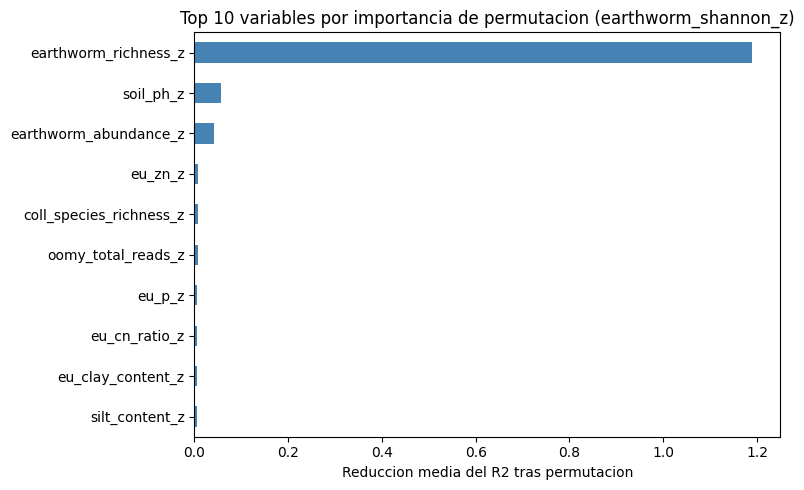


Top 10 coeficientes por valor absoluto:
earthworm_richness_z       0.727482
soil_ph_z                  0.157183
earthworm_abundance_z      0.117063
oomy_total_reads_z         0.052762
eu_zn_z                    0.051156
pb_z                       0.049253
eu_cn_ratio_z              0.047519
coll_species_richness_z    0.047479
eu_p_z                     0.047365
silt_content_z             0.046956


In [ ]:
print('Calculando importancia de variables mediante permutacion sobre X_train...')

modelo_imp = Ridge(**REG_OPTIMAL_PARAMS)
modelo_imp.fit(X_train, y_train['earthworm_shannon_z'].values)

result = permutation_importance(
    modelo_imp, X_train, y_train['earthworm_shannon_z'].values,
    n_repeats=10, random_state=42, n_jobs=-1
)

importancias = pd.Series(result.importances_mean, index=FEATURES_AUTORIZADAS)
top10 = importancias.nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Reduccion media del R2 tras permutacion')
ax.set_title('Top 10 variables por importancia de permutacion (earthworm_shannon_z)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Coeficientes directos del modelo
coefs = pd.Series(modelo_imp.coef_, index=FEATURES_AUTORIZADAS)
print('\nTop 10 coeficientes por valor absoluto:')
print(coefs.abs().nlargest(10).to_string())


## 6.- Entrenamiento de produccion

La regresion lineal es determinista (no depende de semillas aleatorias), por lo que se entrena un unico modelo por variable objetivo. Cada modelo se guarda en disco en formato `.pkl`.

In [6]:
print('Entrenamiento de produccion (un modelo por target, sin ensamble)...')
print('-' * 70)
print('Nota: la regresion lineal es determinista; no es necesario variar semillas.')
print('      Se guarda un unico modelo por variable objetivo.')
print('-' * 70)

global_start = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    model = Ridge(**REG_OPTIMAL_PARAMS)
    model.fit(X_train, y)

    ruta = os.path.join(MODELS_DIR, f'ridge_prod_{target_col}.pkl')
    joblib.dump(model, ruta)

    print(f'  [{idx}/{len(TARGETS)}] {target_col:30} completado ({time.time()-t0:.2f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start):.1f} segundos.')
print(f'Modelos guardados: {len(TARGETS)}')


Entrenamiento de produccion (un modelo por target, sin ensamble)...
----------------------------------------------------------------------
Nota: la regresion lineal es determinista; no es necesario variar semillas.
      Se guarda un unico modelo por variable objetivo.
----------------------------------------------------------------------
  [1/11] nematode_shannon_z             completado (0.00s)
  [2/11] macro_shannon_z                completado (0.01s)
  [3/11] earthworm_shannon_z            completado (0.00s)
  [4/11] orib_shannon_z                 completado (0.00s)
  [5/11] meso_shannon_z                 completado (0.00s)
  [6/11] coll_shannon_z                 completado (0.00s)
  [7/11] bac_shannon_z                  completado (0.00s)
  [8/11] fun_shannon_z                  completado (0.00s)
  [9/11] euk_shannon_z                  completado (0.00s)
  [10/11] oomy_shannon_z                 completado (0.00s)
  [11/11] cerc_shannon_z                 completado (0.00s)
--------

## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

In [7]:
test_target = 'earthworm_shannon_z'

# Evaluacion final sobre eval.csv
print('Evaluacion final sobre eval.csv')
print('-' * 50)

ruta        = os.path.join(MODELS_DIR, f'ridge_prod_{test_target}.pkl')
modelo_eval = joblib.load(ruta)
y_pred_eval = modelo_eval.predict(X_eval)
y_true_eval = y_eval[test_target].values

print(f'  R2   : {r2_score(y_true_eval, y_pred_eval):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_true_eval, y_pred_eval)):.4f} puntos de Shannon H\'')
print(f'  MAE  : {mean_absolute_error(y_true_eval, y_pred_eval):.4f} puntos de Shannon H\'')

# Smoke test
print('\nSmoke test -- inferencia con datos nuevos')
print('-' * 50)

try:
    df_new  = pd.DataFrame(np.random.rand(3, len(FEATURES_AUTORIZADAS)), columns=FEATURES_AUTORIZADAS)
    pred    = modelo_eval.predict(df_new)
    print(f'  Prediccion sobre 3 muestras nuevas: {np.round(pred, 4)}')
    print('\nSmoke test superado. El pipeline funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')


Evaluacion final sobre eval.csv
--------------------------------------------------
  R2   : 0.8328
  RMSE : 0.4082 puntos de Shannon H'
  MAE  : 0.3328 puntos de Shannon H'

Smoke test -- inferencia con datos nuevos
--------------------------------------------------
  Prediccion sobre 3 muestras nuevas: [0.5423 0.8037 0.2519]

Smoke test superado. El pipeline funciona correctamente.
